# Seaborn Exercises - Student Mental Health Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Student_Mental_health.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (101, 11)

Column names:
['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']

First few rows:


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Exercise 1: Visualizing the Distribution of CGPA

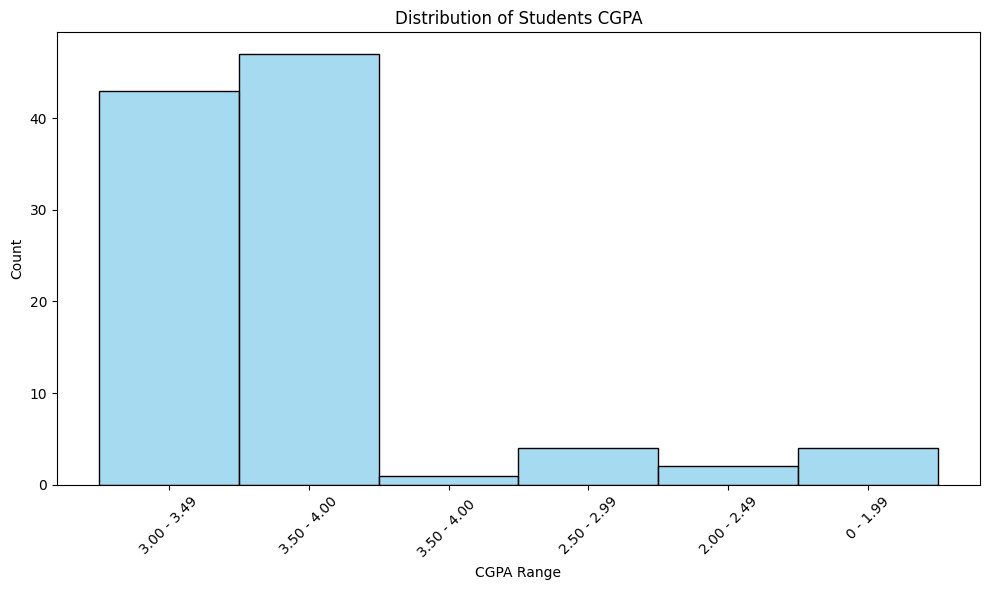

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='What is your CGPA?', color='skyblue')
plt.title('Distribution of Students CGPA')
plt.xlabel('CGPA Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Exercise 2: Comparing Anxiety Levels Across Different Genders

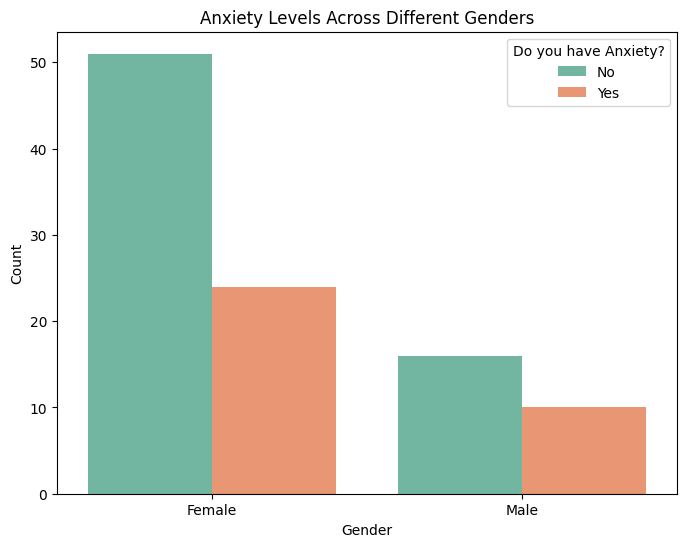

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Choose your gender', hue='Do you have Anxiety?', palette='Set2')
plt.title('Anxiety Levels Across Different Genders')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## Exercise 3: Exploring the Relationship Between Age and Panic Attacks

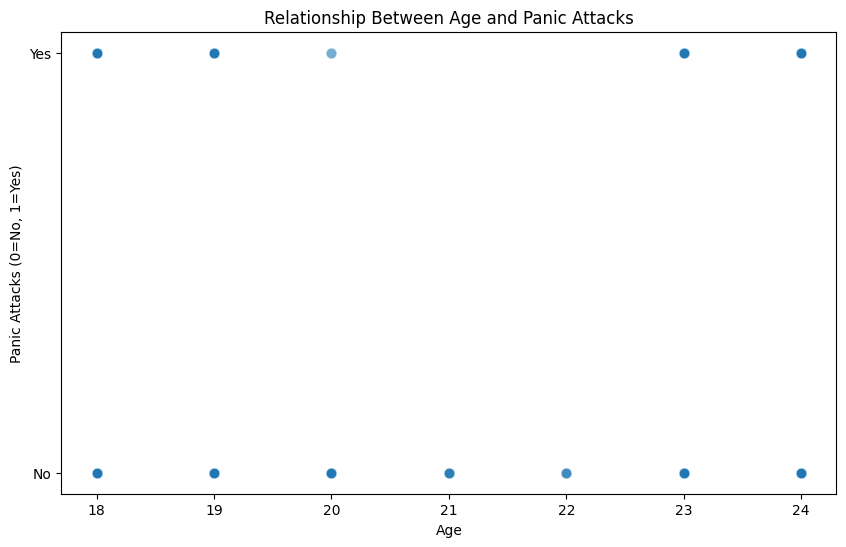

In [ ]:
# Convert panic attacks to numeric
df['Panic_numeric'] = df['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Panic_numeric', alpha=0.6, s=60)
plt.title('Relationship Between Age and Panic Attacks')
plt.xlabel('Age')
plt.ylabel('Panic Attacks (0=No, 1=Yes)')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

## Exercise 4: Visualizing Pairwise Relationships with Seaborn Pair Plot

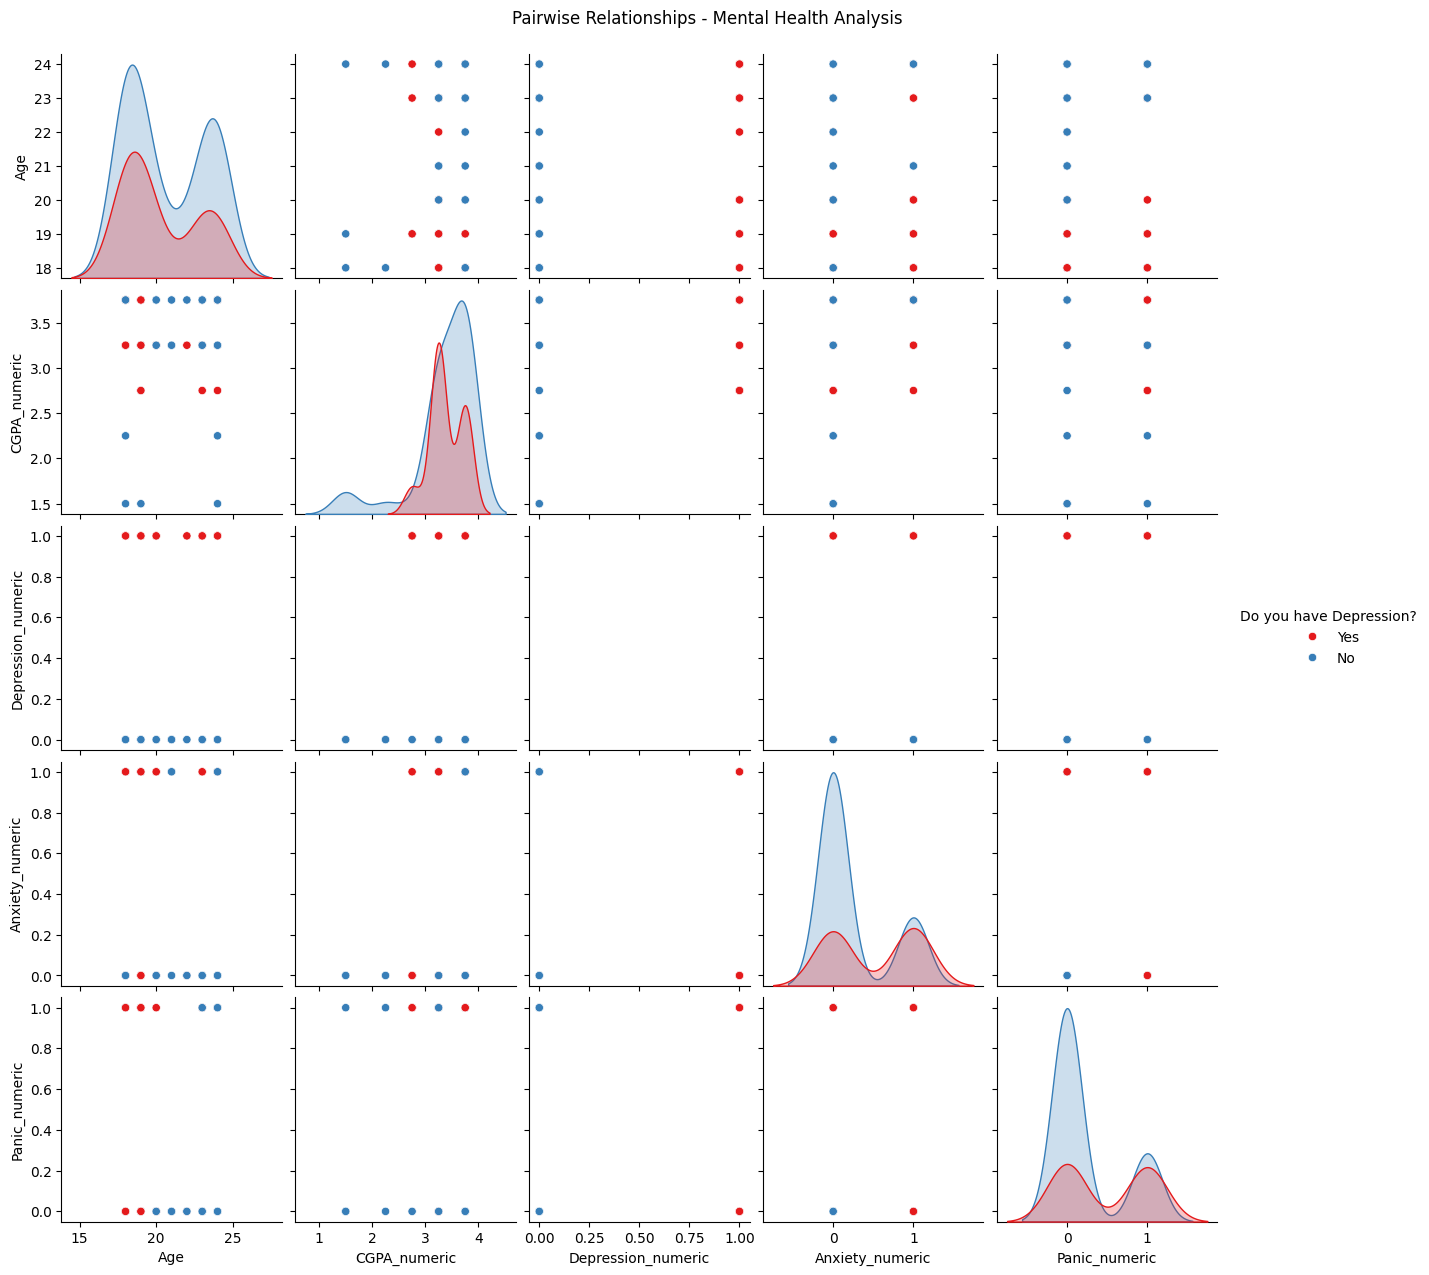

In [ ]:

cgpa_mapping = {
    '0 - 1.99': 1.5,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}
df['CGPA_numeric'] = df['What is your CGPA?'].map(cgpa_mapping)

# Create numeric columns for mental health
df['Depression_numeric'] = df['Do you have Depression?'].map({'Yes': 1, 'No': 0})
df['Anxiety_numeric'] = df['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})

# Select subset for pair plot
subset_cols = ['Age', 'CGPA_numeric', 'Depression_numeric', 'Anxiety_numeric', 'Panic_numeric']
subset_df = df[subset_cols + ['Do you have Depression?']].copy()

sns.pairplot(subset_df, hue='Do you have Depression?', palette='Set1')
plt.suptitle('Pairwise Relationships - Mental Health Analysis', y=1.02)
plt.show()

## Exercise 5: Creating a Heatmap to Visualize Correlations

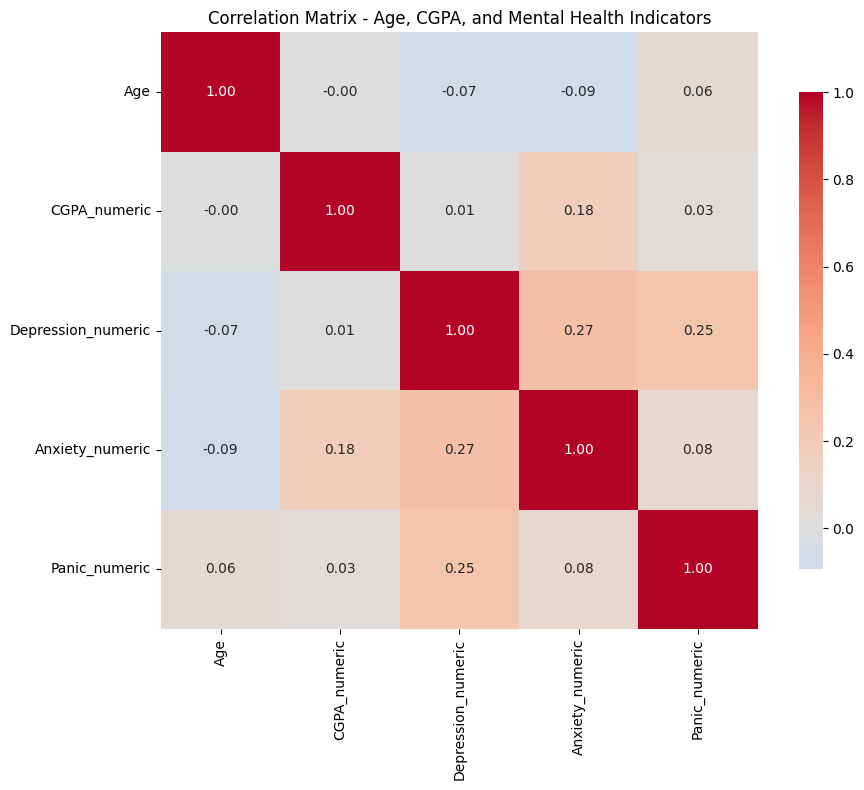

In [ ]:

corr_cols = ['Age', 'CGPA_numeric', 'Depression_numeric', 'Anxiety_numeric', 'Panic_numeric']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Age, CGPA, and Mental Health Indicators')
plt.tight_layout()
plt.show()

## Exercise 6: Analyzing Distributions Using FacetGrid

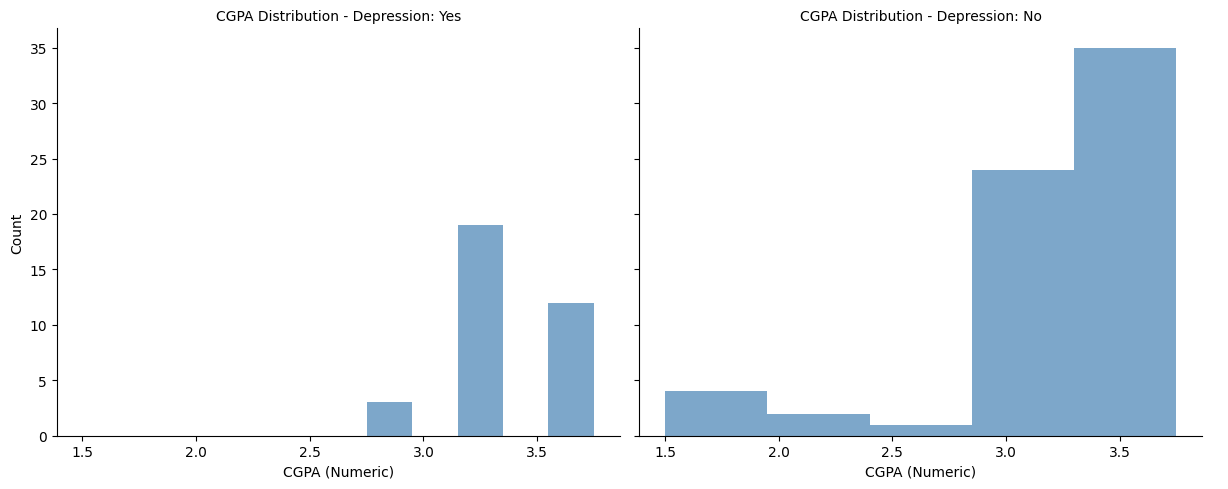

In [ ]:
g = sns.FacetGrid(df, col='Do you have Depression?', height=5, aspect=1.2)
g.map(plt.hist, 'CGPA_numeric', bins=5, alpha=0.7, color='steelblue')
g.add_legend()
g.set_axis_labels('CGPA (Numeric)', 'Count')
g.set_titles('CGPA Distribution - Depression: {col_name}')
plt.show()